In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'


# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [8]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [9]:
##########################################################
#PLOTTING
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [10]:
#READING DATA BACK IN
type2='general'
type2='cloudy'

import h5py
# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'+f"CL_tracked_profiles_VMF_{res}_{t_res}_{Np_str}.h5"

# Open the file in read mode
with h5py.File(filePath, 'r') as h5f:
    # Load datasets into variables
    CL_ALL_VMF = h5f['CL_ALL_VMF'][:]
    CL_SHALLOW_VMF = h5f['CL_SHALLOW_VMF'][:]
    CL_DEEP_VMF = h5f['CL_DEEP_VMF'][:]

In [11]:
#READING DATA BACK IN
type2='general'
type2='cloudy'

import h5py
# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'+f"nonCL_tracked_profiles_VMF_{res}_{t_res}_{Np_str}.h5"

# Open the file in read mode
with h5py.File(filePath, 'r') as h5f:
    # Load datasets into variables
    nonCL_ALL_VMF = h5f['nonCL_ALL_VMF'][:]
    nonCL_SHALLOW_VMF = h5f['nonCL_SHALLOW_VMF'][:]
    nonCL_DEEP_VMF = h5f['nonCL_DEEP_VMF'][:]


In [12]:
# #********************************


# xlims=[] #FIXING XAXIS
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec

# # List of profile arrays and their corresponding labels and x-axis titles
# profiles = [
#     (CL_ALL_VMF, CL_SHALLOW_VMF, CL_DEEP_VMF, 'VMF', 'CL'),
#     (nonCL_ALL_VMF, nonCL_SHALLOW_VMF, nonCL_DEEP_VMF, 'VMF', 'nonCL')
# ]


# # Set up the 2x3 gridspec
# fig = plt.figure(figsize=(12, 8))
# gs = gridspec.GridSpec(1,2, figure=fig)

# # Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
#     ax = fig.add_subplot(gs[i])
    
#     # Compute the averaged profile
#     ALL_profile = averaged_profiles(ALL_profile_array)
#     SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
#     DEEP_profile = averaged_profiles(DEEP_profile_array)

#     # #TESTING
#     # ##############################
#     # Nx=512;Ny=200;Nt=133;
#     # ALL_profile[:,0]/=(Nx*Ny*Nt)
#     # SHALLOW_profile[:,0]/=(Nx*Ny*Nt)
#     # DEEP_profile[:,0]/=(Nx*Ny*Nt)
#     # ##############################
#     # #TESTING
    
#     # Plot the profile
#     ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL')
#     ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW')
#     ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP')
#     ax.set_xlabel(xlabel)
#     ax.set_title(CLlabel)
#     ax.set_ylabel('z (km)')
#     ax.grid(True)
    

#     #LEGEND
#     ax.legend()
#     # legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
#     # legend_ax.axis("off")  # Hide axes for the legend box
#     # legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

# axs = fig.get_axes()
# ax1,ax2=axs
# fix_x_limits([ax1,ax2])
# fix_y_limits([ax1,ax2])

# #ACCESSORIES
# plt.suptitle(f'CL vs nonCL (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type2.title()} Updraft VMF from Tracked Lagrangian Parcels')
# plt.tight_layout()


# #MEAN CLOUD BASE
# axs = fig.get_axes()
# ax1, ax2= axs
# for axis in [ax1,ax2]:
#     axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

# #SCIENTIFIC NOTATION
# apply_scientific_notation([ax1,ax2])

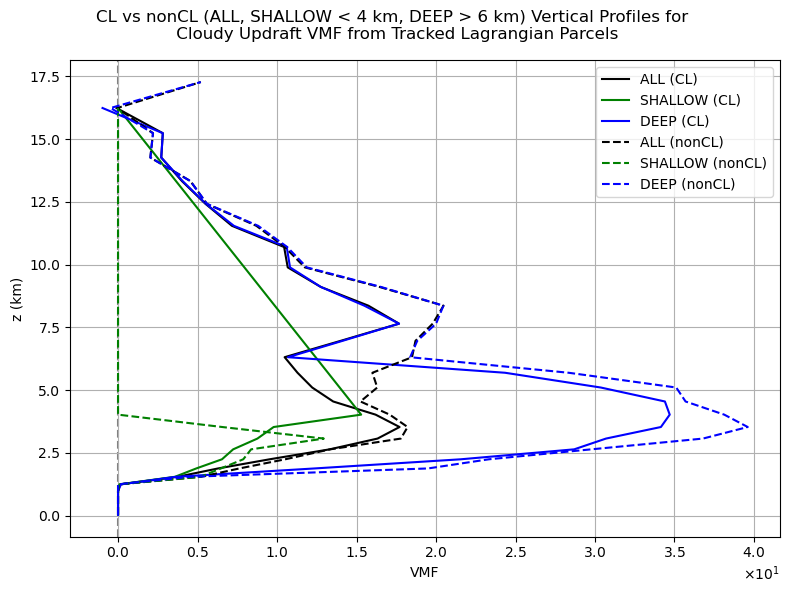

In [28]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (CL_ALL_VMF, CL_SHALLOW_VMF, CL_DEEP_VMF, 'VMF', 'CL'),
    (nonCL_ALL_VMF, nonCL_SHALLOW_VMF, nonCL_DEEP_VMF, 'VMF', 'nonCL')
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(CL_ALL_VMF[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for CL and nonCL
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    # Compute the averaged profile for ALL
    ALL_profile = averaged_profiles(ALL_profile_array) 
    SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    DEEP_profile = averaged_profiles(DEEP_profile_array)

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]
    SHALLOW_profile=SHALLOW_profile[:z_cutoff]
    DEEP_profile=DEEP_profile[:z_cutoff]

    # Plot the profile for ALL (CL and nonCL) on top of each other
    if CLlabel == 'CL':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (CL)')
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (CL)')
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (CL)')
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (nonCL)')
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (nonCL)')
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (nonCL)')

    apply_scientific_notation([ax])

# Add labels and title
ax.set_xlabel('VMF')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

# Set up the main title and adjust layout
plt.suptitle(f'CL vs nonCL (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type2.title()} Updraft VMF from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()



In [ ]:
#######################
#SBZ vs nonSBZ

In [14]:
##########################################################
#PLOTTING

In [15]:
#READING DATA BACK IN
type2='general'
# type2='cloudy'

# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'
filePath+=f'SBZ_tracked_profiles_{res}_{t_res}_{Np_str}.h5'

# Read datasets from the HDF5 file
with h5py.File(filePath, 'r') as h5f:
    SBZ_ALL_VMF = h5f['SBZ_ALL_VMF'][:]
    SBZ_SHALLOW_VMF = h5f['SBZ_SHALLOW_VMF'][:]
    SBZ_DEEP_VMF = h5f['SBZ_DEEP_VMF'][:]

In [16]:
#READING DATA BACK IN
type2='general'
# type2='cloudy'

# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'
filePath+=f'nonSBZ_tracked_profiles_{res}_{t_res}_{Np_str}.h5'

# Read datasets from the HDF5 file
with h5py.File(filePath, 'r') as h5f:
    nonSBZ_ALL_VMF = h5f['nonSBZ_ALL_VMF'][:]
    nonSBZ_SHALLOW_VMF = h5f['nonSBZ_SHALLOW_VMF'][:]
    nonSBZ_DEEP_VMF = h5f['nonSBZ_DEEP_VMF'][:]

In [17]:
# #********************************


# xlims=[] #FIXING XAXIS
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec

# # List of profile arrays and their corresponding labels and x-axis titles
# profiles = [
#     (SBZ_ALL_VMF, SBZ_SHALLOW_VMF, SBZ_DEEP_VMF, 'VMF', 'SBZ'),
#     (nonSBZ_ALL_VMF, nonSBZ_SHALLOW_VMF, nonSBZ_DEEP_VMF, 'VMF', 'nonSBZ')
# ]


# # Set up the 2x3 gridspec
# fig = plt.figure(figsize=(12, 8))
# gs = gridspec.GridSpec(1,2, figure=fig)

# # Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, SBZlabel) in enumerate(profiles):
#     ax = fig.add_subplot(gs[i])
    
#     # Compute the averaged profile
#     ALL_profile = averaged_profiles(ALL_profile_array)
#     SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
#     DEEP_profile = averaged_profiles(DEEP_profile_array)

#     # #TESTING
#     # ##############################
#     # Nx=512;Ny=200;Nt=133;
#     # ALL_profile[:,0]/=(Nx*Ny*Nt)
#     # SHALLOW_profile[:,0]/=(Nx*Ny*Nt)
#     # DEEP_profile[:,0]/=(Nx*Ny*Nt)
#     # ##############################
#     # #TESTING
    
#     # Plot the profile
#     ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL')
#     ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW')
#     ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP')
#     ax.set_xlabel(xlabel)
#     ax.set_title(SBZlabel)
#     ax.set_ylabel('z (km)')
#     ax.grid(True)
    

#     #LEGEND
#     ax.legend()
#     # legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
#     # legend_ax.axis("off")  # Hide axes for the legend box
#     # legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

# axs = fig.get_axes()
# ax1,ax2=axs
# fix_x_limits([ax1,ax2])
# fix_y_limits([ax1,ax2])

# #ACCESSORIES
# plt.suptitle(f'SBZ vs nonSBZ (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type2.title()} Updraft VMF from Tracked Lagrangian Parcels')
# plt.tight_layout()


# #MEAN CLOUD BASE
# axs = fig.get_axes()
# ax1, ax2= axs
# for axis in [ax1,ax2]:
#     axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

# #SCIENTIFIC NOTATION
# apply_scientific_notation([ax1,ax2])

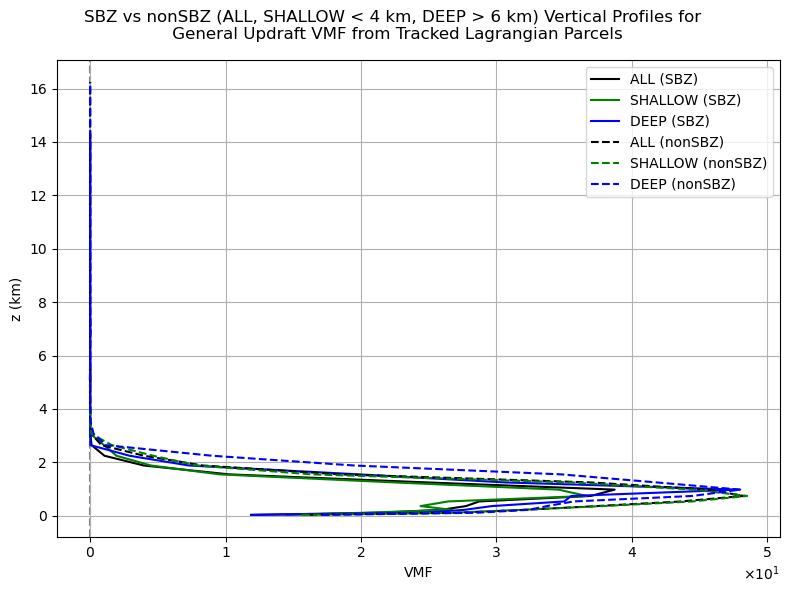

In [18]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_ALL_VMF, SBZ_SHALLOW_VMF, SBZ_DEEP_VMF, 'VMF', 'SBZ'),
    (nonSBZ_ALL_VMF, nonSBZ_SHALLOW_VMF, nonSBZ_DEEP_VMF, 'VMF', 'nonSBZ')
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(SBZ_ALL_VMF[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for SBZ and nonSBZ
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, SBZlabel) in enumerate(profiles):
    # Compute the averaged profile for ALL
    ALL_profile = averaged_profiles(ALL_profile_array)
    SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    DEEP_profile = averaged_profiles(DEEP_profile_array)

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]
    SHALLOW_profile=SHALLOW_profile[:z_cutoff]
    DEEP_profile=DEEP_profile[:z_cutoff]

    # Plot the profile for ALL (SBZ and nonSBZ) on top of each other
    if SBZlabel == 'SBZ':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (SBZ)')
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (SBZ)')
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (SBZ)')
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (nonSBZ)')
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (nonSBZ)')
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (nonSBZ)')

    apply_scientific_notation([ax])

# Add labels and title
ax.set_xlabel('VMF')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

# Set up the main title and adjust layout
plt.suptitle(f'SBZ vs nonSBZ (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type2.title()} Updraft VMF from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()



In [ ]:
#COLDPOOL

In [19]:
#PLOTTING
###################################

In [24]:
#READING DATA BACK IN
type2='general'
type2='cloudy'

# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'
filePath+=f'SBZ_tracked_profiles_{res}_{t_res}_{Np_str}.h5'

# Read datasets from the HDF5 file
with h5py.File(filePath, 'r') as h5f:
    SBZ_ALL_VMF = h5f['SBZ_ALL_VMF'][:]
    SBZ_SHALLOW_VMF = h5f['SBZ_SHALLOW_VMF'][:]
    SBZ_DEEP_VMF = h5f['SBZ_DEEP_VMF'][:]

In [25]:
#READING DATA BACK IN
type2='general'
type2='cloudy'

# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'
filePath+=f'ColdPool_tracked_profiles_{res}_{t_res}{Np_str}.h5'

# Read datasets from the HDF5 file
with h5py.File(filePath, 'r') as h5f:
    ColdPool_ALL_VMF = h5f['ColdPool_ALL_VMF'][:]
    ColdPool_SHALLOW_VMF = h5f['ColdPool_SHALLOW_VMF'][:]
    ColdPool_DEEP_VMF = h5f['ColdPool_DEEP_VMF'][:]

In [26]:
# #********************************


# xlims=[] #FIXING XAXIS
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec

# # List of profile arrays and their corresponding labels and x-axis titles
# profiles = [
#     (SBZ_ALL_VMF, SBZ_SHALLOW_VMF, SBZ_DEEP_VMF, 'VMF', 'SBZ'),
#     (ColdPool_ALL_VMF, ColdPool_SHALLOW_VMF, ColdPool_DEEP_VMF, 'VMF', 'ColdPool')
# ]


# # Set up the 2x3 gridspec
# fig = plt.figure(figsize=(12, 8))
# gs = gridspec.GridSpec(1,2, figure=fig)

# # Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, SBZlabel) in enumerate(profiles):
#     ax = fig.add_subplot(gs[i])
    
#     # Compute the averaged profile
#     ALL_profile = averaged_profiles(ALL_profile_array)
#     SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
#     DEEP_profile = averaged_profiles(DEEP_profile_array)

#     # #TESTING
#     # ##############################
#     # Nx=512;Ny=200;Nt=133;
#     # ALL_profile[:,0]/=(Nx*Ny*Nt)
#     # SHALLOW_profile[:,0]/=(Nx*Ny*Nt)
#     # DEEP_profile[:,0]/=(Nx*Ny*Nt)
#     # ##############################
#     # #TESTING
    
#     # Plot the profile
#     ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL')
#     ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW')
#     ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP')
#     ax.set_xlabel(xlabel)
#     ax.set_title(SBZlabel)
#     ax.set_ylabel('z (km)')
#     ax.grid(True)
    

#     #LEGEND
#     ax.legend()
#     # legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
#     # legend_ax.axis("off")  # Hide axes for the legend box
#     # legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

# axs = fig.get_axes()
# ax1,ax2=axs
# fix_x_limits([ax1,ax2])
# fix_y_limits([ax1,ax2])

# #ACCESSORIES
# plt.suptitle(f'SBZ vs ColdPool (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type2.title()} Updraft VMF from Tracked Lagrangian Parcels')
# plt.tight_layout()


# #MEAN CLOUD BASE
# axs = fig.get_axes()
# ax1, ax2= axs
# for axis in [ax1,ax2]:
#     axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

# #SCIENTIFIC NOTATION
# apply_scientific_notation([ax1,ax2])

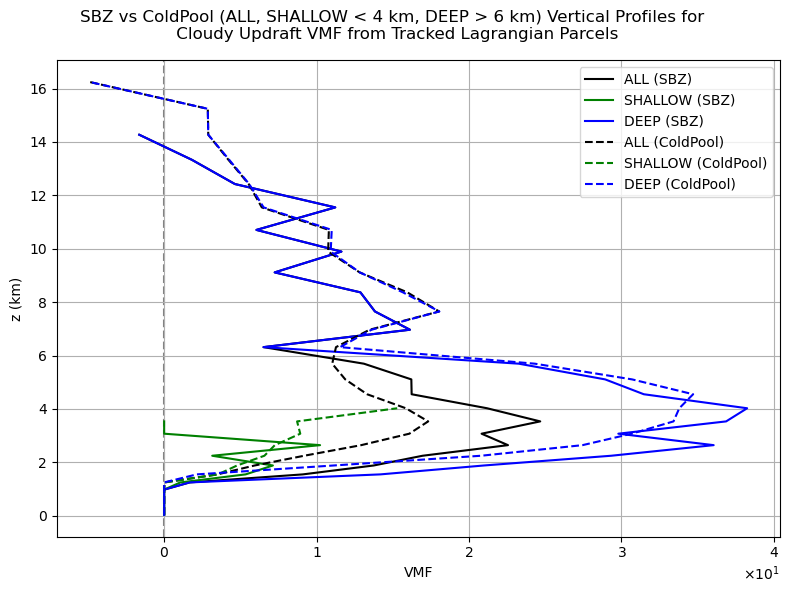

In [27]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_ALL_VMF, SBZ_SHALLOW_VMF, SBZ_DEEP_VMF, 'VMF', 'SBZ'),
    (ColdPool_ALL_VMF, ColdPool_SHALLOW_VMF, ColdPool_DEEP_VMF, 'VMF', 'ColdPool')
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(SBZ_ALL_VMF[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for SBZ and ColdPool
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, SBZlabel) in enumerate(profiles):
    # Compute the averaged profile for ALL
    ALL_profile = averaged_profiles(ALL_profile_array)
    SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    DEEP_profile = averaged_profiles(DEEP_profile_array)

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]
    SHALLOW_profile=SHALLOW_profile[:z_cutoff]
    DEEP_profile=DEEP_profile[:z_cutoff]

    # Plot the profile for ALL (SBZ and ColdPool) on top of each other
    if SBZlabel == 'SBZ':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (SBZ)')
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (SBZ)')
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (SBZ)')
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (ColdPool)')
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (ColdPool)')
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (ColdPool)')

    apply_scientific_notation([ax])

# Add labels and title
ax.set_xlabel('VMF')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

# Set up the main title and adjust layout
plt.suptitle(f'SBZ vs ColdPool (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type2.title()} Updraft VMF from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()

